In [172]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

Создаем карту 6*6,
параметр р определет процент соотношения прорубей и целых квадратов. Ставим 0.9 чтобы обучить на более легких картах

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
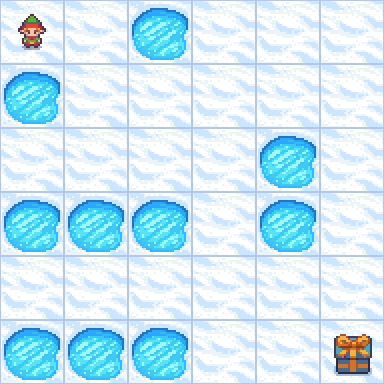

In [390]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
environment=gym.make('FrozenLake-v1', is_slippery=False, desc=generate_random_map(size=6),
                     render_mode='rgb_array')
# переведем игру в начальное состояние и
environment.reset()
# визуализируем среду
environment.render()

Создаем Q-таблицу

In [391]:
n_states = environment.observation_space.n
n_actions = environment.action_space.n

qtable = np.zeros((n_states, n_actions))

Обучение

In [392]:

# вновь создадим Q-таблицу, заполненную нулями
qtable = np.zeros((environment.observation_space.n, environment.action_space.n))

# агент будет учиться в течение 1000 эпизодов
episodes = 10000
# будем учитывать успешность каждого эпизода
success = []

# для каждого эпизода
for _ in range(episodes):
  # вернем игру в начальное состояние
  state = environment.reset()[0]
  # объявим переменную окончания эпизода
  # (по умолчанию, ее значение будет False)
  terminated = False
  # по умолчанию, будем считать эпизод неудачным
  success.append(0)

  # во внутреннем цикле будем проходить эпизод до тех пор,
  # пока не попровалимся под лед или не дойдем до цели
  # т.е. пока переменная terminated не примет значение True
  while not terminated:

    # на каждой итерации эпизода будем делать шаг action и
    # получать информацию о новом состоянии, вознаграждении и
    # факте завершения эпизода

    if np.max(qtable[state]) > 0:
      action = np.argmax(qtable[state])
    else:
      action = environment.action_space.sample()

    new_state, reward, terminated, *_ = environment.step(action)

    qtable[state, action] = reward + np.max(qtable[new_state])

    state = new_state  # также не забудем обновить текущее состояние

    # если же текущий эпизод закончится получением награды,
    if reward:
       # изменим запись о нем с нуля на единицу
      success[-1] = 1

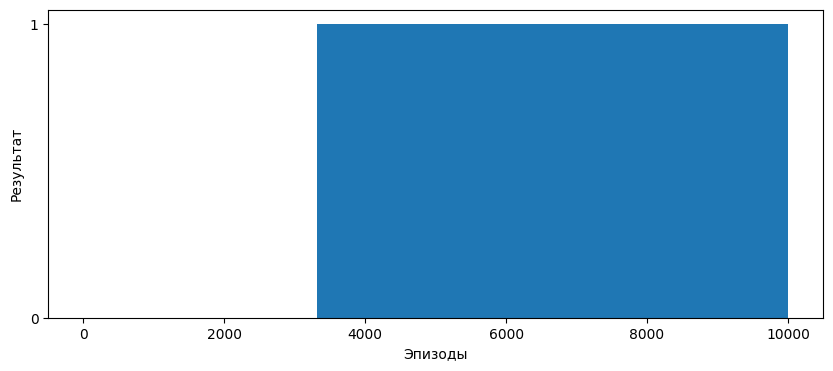

In [393]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(success)), success, width=1.0)
plt.xlabel('Эпизоды')
plt.yticks([0,1])
plt.ylabel('Результат')
plt.show()

In [394]:
qtable

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
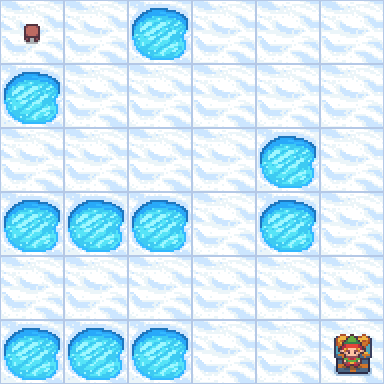

In [395]:
environment.render()

In [396]:
episodes = 10
n_success = 0

for _ in range(episodes):

  state = environment.reset()[0]
  terminated = False

  while not terminated:

    action = np.argmax(qtable[state])
    new_state, reward, terminated, *_ = environment.step(action)
    state = new_state

    n_success += reward

n_success/episodes

1.0

In [397]:
# отследим ходы агента
sequence = []
state = environment.reset()[0]
terminated = False

while not terminated:
  action = np.argmax(qtable[state])
  sequence.append(int(action))
  new_state, _, terminated, *_ = environment.step(action)
  state = new_state

sequence

[2, 1, 1, 2, 2, 1, 1, 2, 2, 1]

2. Q(st,at)=(1−α)Q(st,at)+α(Rt+1+maxaQ(st+1,a))

In [405]:
qtable = np.zeros((n_states, n_actions))
episodes = 10000
alpha = 0.1
success=[]
for _ in range(episodes):

  state = environment.reset()[0]
  terminated = False
  success.append(0)

  while not terminated:

    if np.max(qtable[state]) > 0:
      action = np.argmax(qtable[state])
    else:
      action = environment.action_space.sample()

    new_state, reward, terminated, *_ = environment.step(action)

    # обратная косая черта позволяет перенести код
    # на следующую строку
    qtable[state, action] = (1-alpha) * qtable[state, action] + \
                            alpha * (reward + np.max(qtable[new_state]))

    state = new_state

    if reward:
       success[-1]=1

In [406]:
qtable

array([[0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 2.26e-06, 0.00e+00, 0.00e+00],
       [0.00e+00, 1.00e-06, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [0.00e+00, 0.

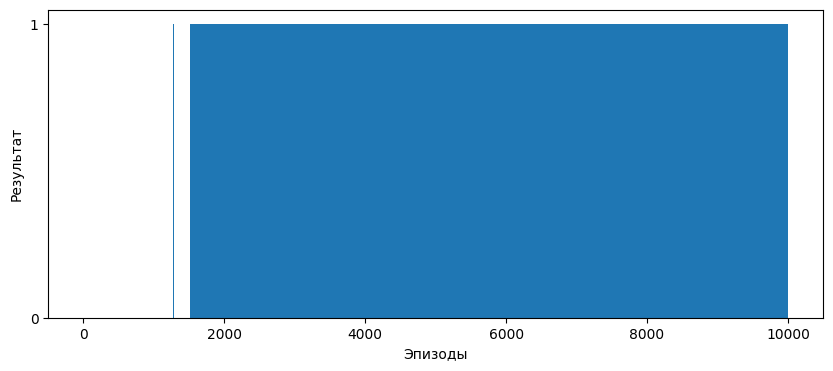

In [407]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(success)), success, width=1.0)
plt.xlabel('Эпизоды')
plt.yticks([0,1])
plt.ylabel('Результат')
plt.show()

In [408]:
# отследим ходы агента
sequence = []
state = environment.reset()[0]
terminated = False

while not terminated:
  action = np.argmax(qtable[state])
  sequence.append(int(action))
  new_state, _, terminated, *_ = environment.step(action)
  state = new_state

sequence

[2, 1, 1, 2, 2, 1, 1, 2, 1, 2]

In [409]:
episodes = 1000
n_success = 0

for _ in range(episodes):

  state = environment.reset()[0]
  terminated = False

  while not terminated:

    action = np.argmax(qtable[state])
    new_state, reward, terminated, *_ = environment.step(action)
    state = new_state

    n_success += reward

n_success/episodes

1.0

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
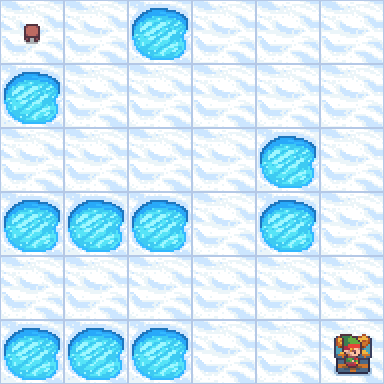

In [410]:
environment.render()

3.Q(st,at)=Q(st,at)+α(Rt+1+γmaxaQ(st+1,a)−Q(st,at))

In [414]:
qtable = np.zeros((environment.observation_space.n, environment.action_space.n))

episodes = 10000
alpha = 0.1     # коэффициент скорости обучения
gamma = 0.9     # коэффициент дисконтирования
qtables = []    # список для значений Q-таблицы
success = []
for _ in range(episodes):
  state = environment.reset()[0]
  terminated = False
  success.append(0)
  while not terminated:

    if np.max(qtable[state]) > 0:
      action = np.argmax(qtable[state])
    else:
      action = environment.action_space.sample()

    new_state, reward, terminated, *_ = environment.step(action)

    qtable[state, action] = qtable[state, action] + \
    alpha * (reward + gamma * np.max(qtable[new_state]) - qtable[state, action])

    state = new_state


    # каждый раз при достижении цели
    if reward:
      # поместим обновленную Q-таблицы в список
      success[-1]=1
      qtables.append(qtable.copy())


In [415]:
qtable

array([[0.00000000e+00, 0.00000000e+00, 3.87420489e-01, 0.00000000e+00],
       [0.00000000e+00, 4.30467210e-01, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.56100000e-06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 4.78296900e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.31441000e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.90490000e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 6.56100000e-01, 0.00000000e+00],
       [0.00000000e+00, 7.29000000e-01, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e

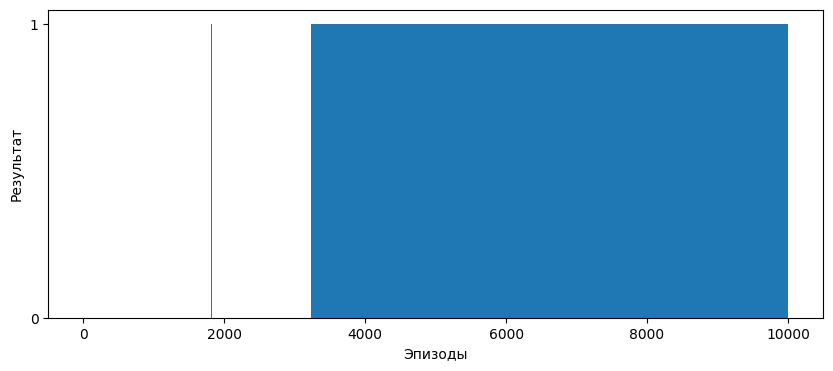

In [416]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(success)), success, width=1.0)
plt.xlabel('Эпизоды')
plt.yticks([0,1])
plt.ylabel('Результат')
plt.show()

In [417]:
# отследим ходы агента
sequence = []
state = environment.reset()[0]
terminated = False

while not terminated:
  action = np.argmax(qtable[state])
  sequence.append(int(action))
  new_state, _, terminated, *_ = environment.step(action)
  state = new_state

sequence

[2, 1, 2, 2, 2, 2, 1, 1, 1, 1]

In [418]:
episodes = 1000
n_success = 0

for _ in range(episodes):

  state = environment.reset()[0]
  terminated = False

  while not terminated:

    action = np.argmax(qtable[state])
    new_state, reward, terminated, *_ = environment.step(action)
    state = new_state

    n_success += reward

n_success/episodes

1.0

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
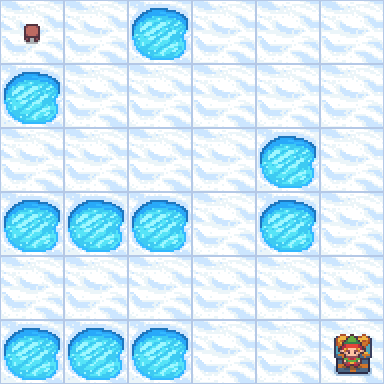

In [419]:
environment.render()

4.ϵ -жадный алгоритм

In [423]:
qtable = np.zeros((environment.observation_space.n, environment.action_space.n))

episodes = 6000
alpha = 0.5
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.001

success = []

for _ in range(episodes):
  state = environment.reset()[0]
  terminated = False

  success.append(0)

  while not terminated:

    num = np.random.random()
    if num < epsilon:
      action = environment.action_space.sample()
    else:
      action = np.argmax(qtable[state])

    new_state, reward, terminated, *_ = environment.step(action)

    qtable[state, action] = qtable[state, action] + \
    alpha * (reward + gamma * np.max(qtable[new_state]) - qtable[state, action])

    state = new_state

    if reward:
      success[-1] = 1

  epsilon = max(epsilon - epsilon_decay, 0)

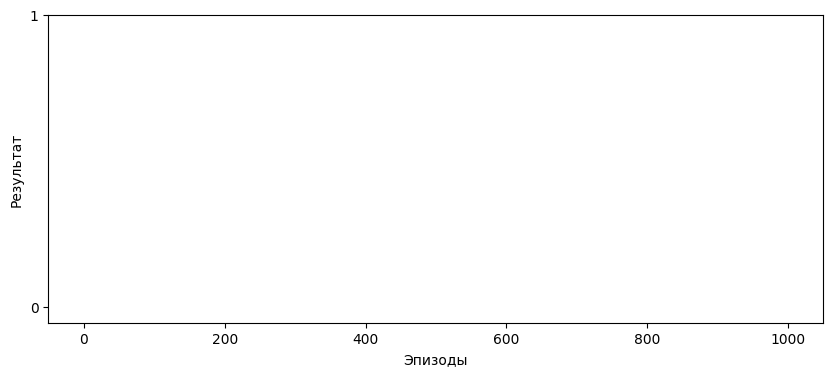

In [424]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(success)), success, width=1.0)
plt.xlabel('Эпизоды')
plt.yticks([0,1])
plt.ylabel('Результат')
plt.show()

In [425]:
qtable

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [381]:
episodes = 1000
n_success = 0

for _ in range(episodes):

  state = environment.reset()[0]
  terminated = False

  while not terminated:

    action = np.argmax(qtable[state])
    new_state, reward, terminated, *_ = environment.step(action)
    state = new_state

    n_success += reward

n_success/episodes

KeyboardInterrupt: 

In [371]:
# отследим ходы агента
sequence = []
state = environment.reset()[0]
terminated = False

while not terminated:
  action = np.argmax(qtable[state])
  sequence.append(int(action))
  new_state, _, terminated, *_ = environment.step(action)
  state = new_state

sequence

[2, 2, 1, 2, 2, 1, 2, 1, 1, 1]

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
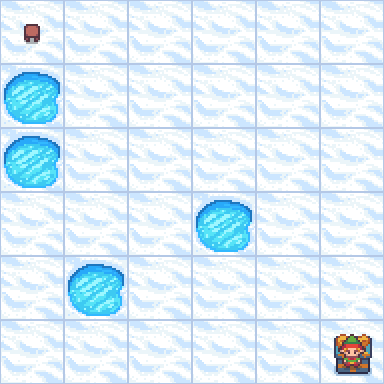

In [363]:
environment.render()

2. Q(st,at)=(1−α)Q(st,at)+α(Rt+1+maxaQ(st+1,a))

3. Q(st,at)=Q(st,at)+α(Rt+1+γmaxaQ(st+1,a)−Q(st,at))

4. ϵ -жадный алгоритм